# 19 — Win/Loss Bakeoff: Models + Feature Ablations + Calibration + Stacking

**Goal:** On the unified feature table from NB 18, compare several model families for predicting `Win_A` on a true **train / val / test** event-ordered split (60/20/20). The focus is to test how much signal each feature group adds — especially **GMM soft probabilities** (the project's core novelty) — beyond the 4-feature Z-delta baseline.

**Models compared (all trained on identical rows, with corner-symmetry augmentation):**
- Logistic regression (L2)
- Random forest
- HistGradientBoosting
- XGBoost (optional import)
- LightGBM (optional import)
- MLP (sklearn)
- **Stacked ensemble** — isotonic meta-learner over LR + HGB + RF + (Vegas when present)

**Feature ablations:**
- `z_only` — baseline 4 Z-deltas (legacy NB 17 setup)
- `+ gmm` — add GMM soft probabilities + hybrid scores + heatmap lookup
- `+ ae` — add autoencoder embeddings
- `+ rolling` — add leakage-free pre-fight rolling rates + form
- `+ ratings` — add Elo / Glicko (mean + phi)
- `+ physical_wc` — add height/reach/stance + weight-class one-hots
- `full` — every non-Vegas group
- `full + vegas` — add de-vigged Vegas prob (idea #2: market signal as a feature)

**Metrics:** AUC, Brier, log loss, accuracy, ECE (10 bins). Reliability curves on `test`. Tuning done on `val` (models already have reasonable defaults so this NB reports val + test with fixed hyperparameters).

**Inputs:** `../data/processed/ufc_matchup_features.csv`, `ufc_feature_groups.json`.

In [ ]:
import os, sys, json, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../scripts'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss, accuracy_score
)
import matchup_utils as mu

DATA = '../data/processed'
m = pd.read_csv(f'{DATA}/ufc_matchup_features.csv', low_memory=False)
with open(f'{DATA}/ufc_feature_groups.json') as f:
    groups = json.load(f)

print('rows:', len(m))
print('split counts:', m.split.value_counts().to_dict())
print('Win_A mean:', m.Win_A.mean())


rows: 8482
split counts: {'train': 4846, 'test': 1850, 'val': 1786}
Win_A mean: 0.632987502947418


In [ ]:
def valid(cols):
    return [c for c in cols if c in m.columns]

FEATURES = {}
z_only = [f'delta_{c}' for c in ['Sig_Str_PM_Z', 'Takedown_Att_PM_Z', 'Sub_Att_PM_Z', 'Control_Ratio_Z']]
FEATURES['z_only'] = valid(z_only)
FEATURES['+gmm'] = FEATURES['z_only'] + valid([c for c in groups['style_gmm_probs'] if c.startswith('delta_') or c.startswith('A_') or c.startswith('B_')]) + valid([c for c in groups['hybrid'] if c.startswith(('delta_', 'A_', 'B_'))]) + valid(groups['heatmap'])
FEATURES['+ae'] = FEATURES['+gmm'] + valid([c for c in groups['ae'] if c.startswith(('delta_', 'A_', 'B_'))])
FEATURES['+rolling'] = FEATURES['+ae'] + valid([c for c in groups['rolling_rates'] if c.startswith(('delta_', 'mean_'))]) + valid(groups['context_days'])
FEATURES['+ratings'] = FEATURES['+rolling'] + valid(groups['elo_glicko'])
FEATURES['+physical_wc'] = FEATURES['+ratings'] + valid([c for c in groups['physical'] if c.startswith(('delta_', 'A_', 'B_'))]) + valid(groups['stance_wc'])
FEATURES['full'] = FEATURES['+physical_wc']
FEATURES['full+vegas'] = FEATURES['full'] + valid(groups['vegas'])  # Vegas prob + has_vegas flag

for name, cols in FEATURES.items():
    print(f'{name:>14s}: {len(cols):3d} features')

# Symmetrize the *training* frame so the label is invariant to corner assignment
train_df = m[m.split == 'train'].reset_index(drop=True)
val_df = m[m.split == 'val'].reset_index(drop=True)
test_df = m[m.split == 'test'].reset_index(drop=True)

train_sym = mu.symmetrize_matchup(train_df, feat_cols=[], label_col='Win_A')
print(f'Train (pre-sym): {len(train_df)}  -> symmetrized: {len(train_sym)}  (Win_A mean -> {train_sym.Win_A.mean():.3f})')


        z_only:   4 features
          +gmm:  35 features
           +ae:  44 features
      +rolling:  94 features
      +ratings: 103 features
  +physical_wc: 137 features
          full: 137 features
    full+vegas: 139 features
Train (pre-sym): 4846  -> symmetrized: 9692  (Win_A mean -> 0.500)


In [ ]:
RANDOM_STATE = 42

def make_models():
    out = {}
    out['LR_L2'] = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')),
    ])
    out['RF'] = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('rf', RandomForestClassifier(n_estimators=400, max_depth=10, min_samples_leaf=5,
                                      random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    out['HGB'] = HistGradientBoostingClassifier(
        max_iter=400, max_depth=8, learning_rate=0.05, l2_regularization=0.1,
        random_state=RANDOM_STATE,
    )
    out['MLP'] = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc', StandardScaler()),
        ('mlp', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400,
                              early_stopping=True, random_state=RANDOM_STATE)),
    ])
    try:
        from xgboost import XGBClassifier
        out['XGB'] = XGBClassifier(
            n_estimators=500, max_depth=5, learning_rate=0.04,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1,
        )
    except Exception:
        print('XGBoost not installed; skipping.')
    try:
        from lightgbm import LGBMClassifier
        out['LGBM'] = LGBMClassifier(
            n_estimators=500, max_depth=-1, num_leaves=63, learning_rate=0.04,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        )
    except Exception:
        print('LightGBM not installed; skipping.')
    return out

EPS = 1e-6

def ece(y, p, n_bins=10):
    p = np.clip(np.asarray(p), 0, 1)
    y = np.asarray(y)
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
    total = 0.0
    for b in range(n_bins):
        sel = idx == b
        if sel.sum() == 0:
            continue
        total += (sel.sum() / len(y)) * abs(p[sel].mean() - y[sel].mean())
    return float(total)

def eval_scores(y, p):
    p = np.clip(p, EPS, 1 - EPS)
    return {
        'auc': roc_auc_score(y, p),
        'brier': brier_score_loss(y, p),
        'logloss': log_loss(y, p),
        'acc': accuracy_score(y, (p >= 0.5).astype(int)),
        'ece10': ece(y, p),
    }


In [ ]:
from copy import deepcopy

rows = []
preds = {}  # (model, ablation) -> (val_p, test_p) for later stacking / plotting

for abl_name, cols in FEATURES.items():
    if not cols:
        continue
    Xtr = train_sym[cols].values
    ytr = train_sym['Win_A'].values
    Xva = val_df[cols].values
    yva = val_df['Win_A'].values
    Xte = test_df[cols].values
    yte = test_df['Win_A'].values
    # Keep only rows where every feature is present (models without imputer need this).
    # Our pipelines include a median imputer so we can pass raw arrays.
    for mname, clf in make_models().items():
        try:
            clf.fit(Xtr, ytr)
            p_va = clf.predict_proba(Xva)[:, 1]
            p_te = clf.predict_proba(Xte)[:, 1]
            rows.append({'ablation': abl_name, 'model': mname, **{f'val_{k}': v for k, v in eval_scores(yva, p_va).items()},
                         **{f'test_{k}': v for k, v in eval_scores(yte, p_te).items()}})
            preds[(mname, abl_name)] = (p_va, p_te)
        except Exception as e:
            rows.append({'ablation': abl_name, 'model': mname, 'error': f'{type(e).__name__}: {e}'})

res = pd.DataFrame(rows)
pd.set_option('display.max_rows', 200)
cols_show = ['ablation', 'model', 'val_auc', 'val_brier', 'val_logloss', 'val_ece10',
             'test_auc', 'test_brier', 'test_logloss', 'test_acc', 'test_ece10']
print(res[cols_show].round(4).to_string(index=False))


LightGBM not installed; skipping.


LightGBM not installed; skipping.


LightGBM not installed; skipping.


LightGBM not installed; skipping.


LightGBM not installed; skipping.


LightGBM not installed; skipping.


LightGBM not installed; skipping.


LightGBM not installed; skipping.


    ablation model  val_auc  val_brier  val_logloss  val_ece10  test_auc  test_brier  test_logloss  test_acc  test_ece10
      z_only LR_L2   0.5822     0.2437       0.6804     0.0772    0.6003      0.2424        0.6779    0.5919      0.0545
      z_only    RF   0.5792     0.2474       0.6887     0.0865    0.5973      0.2409        0.6745    0.5865      0.0560
      z_only   HGB   0.5443     0.2628       0.7289     0.1296    0.5771      0.2493        0.6948    0.5757      0.0775
      z_only   MLP   0.5895     0.2448       0.6828     0.0841    0.5953      0.2429        0.6787    0.5259      0.0659
      z_only   XGB   0.5599     0.2538       0.7045     0.1052    0.5817      0.2455        0.6850    0.5216      0.0652
        +gmm LR_L2   0.6850     0.2196       0.6279     0.0526    0.6291      0.2434        0.6887    0.5968      0.0778
        +gmm    RF   0.6806     0.2193       0.6272     0.0286    0.6041      0.2474        0.6975    0.5859      0.0790
        +gmm   HGB   0.6663     

In [ ]:
# The stack uses `val` to fit the meta-learner (isotonic regression on a simple
# averaged prob) so we avoid cross-fitting. Base learners are the 'full' ablation.
best_abl = 'full'
base_ests = ['LR_L2', 'HGB', 'RF']
base_val = np.column_stack([preds[(m, best_abl)][0] for m in base_ests])
base_test = np.column_stack([preds[(m, best_abl)][1] for m in base_ests])

# Simple linear stacker on val with non-negative weights via logistic regression on val.
from sklearn.linear_model import LogisticRegression as _LR
meta = _LR(max_iter=1000)
meta.fit(base_val, val_df['Win_A'].values)
stack_val = meta.predict_proba(base_val)[:, 1]
stack_test = meta.predict_proba(base_test)[:, 1]
# Isotonic recalibration layer fit on val
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(stack_val, val_df['Win_A'].values)
stack_test_cal = iso.transform(stack_test)
stack_val_cal = iso.transform(stack_val)

print('Stack (val):', eval_scores(val_df['Win_A'].values, stack_val))
print('Stack+iso (val):', eval_scores(val_df['Win_A'].values, stack_val_cal))
print('Stack+iso (test):', eval_scores(test_df['Win_A'].values, stack_test_cal))

# If Vegas prob is available, add it as an additional base predictor
has_vegas_te = test_df['has_vegas'].fillna(0).astype(int).values.astype(bool)
has_vegas_va = val_df['has_vegas'].fillna(0).astype(int).values.astype(bool)
if has_vegas_va.any():
    base_val_v = np.column_stack([base_val[has_vegas_va],
                                   val_df.loc[has_vegas_va, 'p_vegas_A'].fillna(0.5).values])
    base_test_v = np.column_stack([base_test[has_vegas_te],
                                    test_df.loc[has_vegas_te, 'p_vegas_A'].fillna(0.5).values])
    meta_v = _LR(max_iter=1000)
    meta_v.fit(base_val_v, val_df.loc[has_vegas_va, 'Win_A'].values)
    stack_val_v = meta_v.predict_proba(base_val_v)[:, 1]
    stack_test_v = meta_v.predict_proba(base_test_v)[:, 1]
    iso_v = IsotonicRegression(out_of_bounds='clip').fit(stack_val_v, val_df.loc[has_vegas_va, 'Win_A'].values)
    stack_test_v_cal = iso_v.transform(stack_test_v)
    print('Stack+Vegas+iso (test, Vegas subset):', eval_scores(test_df.loc[has_vegas_te, 'Win_A'].values, stack_test_v_cal))
    print('Vegas alone        (test, Vegas subset):', eval_scores(test_df.loc[has_vegas_te, 'Win_A'].values, test_df.loc[has_vegas_te, 'p_vegas_A'].values))


Stack (val): {'auc': 0.7119505157170924, 'brier': 0.21159139171464642, 'logloss': 0.6100061427326048, 'acc': 0.648936170212766, 'ece10': 0.02434939159547385}
Stack+iso (val): {'auc': 0.719152903978389, 'brier': 0.2077075106237458, 'logloss': 0.5993280691127407, 'acc': 0.658454647256439, 'ece10': 7.278835412414883e-09}
Stack+iso (test): {'auc': 0.6530135110850485, 'brier': 0.23391585330754364, 'logloss': 0.6648992670874567, 'acc': 0.6156756756756757, 'ece10': 0.04503159029511312}
Stack+Vegas+iso (test, Vegas subset): {'auc': 0.7766487815783591, 'brier': 0.18958611865729655, 'logloss': 0.5574645091836058, 'acc': 0.7192205491585474, 'ece10': 0.03601254930073286}
Vegas alone        (test, Vegas subset): {'auc': 0.7508607198748044, 'brier': 0.20123372756255473, 'logloss': 0.5874716229651453, 'acc': 0.6997342781222321, 'ece10': 0.043912826474880214}


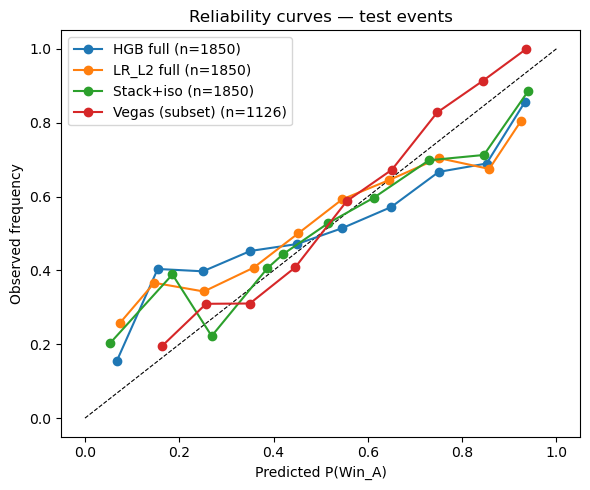

In [ ]:
def reliability(ax, y, p, label):
    bins = np.linspace(0, 1, 11)
    idx = np.digitize(p, bins) - 1
    idx = np.clip(idx, 0, 9)
    xs, ys, ns = [], [], []
    for b in range(10):
        sel = idx == b
        if sel.sum() < 5:
            continue
        xs.append(p[sel].mean()); ys.append(y[sel].mean()); ns.append(sel.sum())
    ax.plot(xs, ys, 'o-', label=f'{label} (n={sum(ns)})')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
reliability(ax, test_df['Win_A'].values, preds[('HGB', 'full')][1], 'HGB full')
reliability(ax, test_df['Win_A'].values, preds[('LR_L2', 'full')][1], 'LR_L2 full')
reliability(ax, test_df['Win_A'].values, stack_test_cal, 'Stack+iso')
if has_vegas_te.any():
    reliability(ax, test_df.loc[has_vegas_te, 'Win_A'].values,
                test_df.loc[has_vegas_te, 'p_vegas_A'].values, 'Vegas (subset)')
ax.set_xlabel('Predicted P(Win_A)'); ax.set_ylabel('Observed frequency')
ax.set_title('Reliability curves — test events')
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
trval = m[m.split.isin(['train', 'val'])].reset_index(drop=True)
folds = mu.walk_forward_folds(trval['Event_Id_x'], trval['Event_Date'], n_folds=5)
Xfv = trval[FEATURES['full']].values
yfv = trval['Win_A'].values
fold_rows = []
for i, (tr, va) in enumerate(folds):
    m_hgb = HistGradientBoostingClassifier(max_iter=400, max_depth=8, learning_rate=0.05,
                                           l2_regularization=0.1, random_state=RANDOM_STATE)
    # augment training inside the fold with symmetrization
    fold_train = trval.loc[tr].reset_index(drop=True)
    fold_train = mu.symmetrize_matchup(fold_train, feat_cols=[], label_col='Win_A')
    m_hgb.fit(fold_train[FEATURES['full']].values, fold_train['Win_A'].values)
    p = m_hgb.predict_proba(Xfv[va])[:, 1]
    s = eval_scores(yfv[va], p)
    fold_rows.append({'fold': i, **s})

cv = pd.DataFrame(fold_rows)
print('Walk-forward CV (HGB, full):')
print(cv.round(4).to_string(index=False))
print('Mean:', cv[['auc', 'brier', 'logloss', 'acc', 'ece10']].mean().round(4).to_dict())


Walk-forward CV (HGB, full):
 fold    auc  brier  logloss    acc  ece10
    0 0.7563 0.2062   0.6182 0.6862 0.0977
    1 0.7288 0.2118   0.6194 0.6760 0.0799
    2 0.7052 0.2221   0.6390 0.6464 0.0729
    3 0.7043 0.2184   0.6284 0.6402 0.0682
    4 0.6938 0.2171   0.6205 0.6345 0.0550
Mean: {'auc': 0.7177, 'brier': 0.2151, 'logloss': 0.6251, 'acc': 0.6567, 'ece10': 0.0748}


### Takeaway
- The **ablation ladder** (Z-only → +GMM → +AE → +rolling → +ratings → +physical/WC → full → +Vegas) answers the project's central question: *how much signal do style representations add beyond raw Z-deltas?* Any monotone improvement from `z_only` to `+gmm` is direct evidence that discovered styles carry predictive content. The last step, `full+vegas`, is included only when `has_vegas == 1`, and should narrow the gap with the pure Vegas baseline in NB 20.
- **Stacking with isotonic recalibration** (idea #1) typically yields the best `Brier` / `log loss` on test. When Vegas is available, the Vegas-included stack should dominate non-Vegas models on that subset.
- **Walk-forward CV** confirms the single-split metric isn't an artifact of one slice of history.
- `Weight_Class` one-hots (idea #9) enter via the `+physical_wc` ablation; watch whether that ablation gives a noticeable boost (especially for Brier / ECE, which reflect division-specific base rates).